# Ejercicio 8 - TP2

Encontrar un perceptrón multicapa que resuelva una XOR de 2 entradas mediante
simulated annealing. Graficar el error a lo largo del proceso de aprendizaje.

### Pasos para el Entrenamiento de la Red Neuronal con Simulated Annealing

1. **Definir la estructura de la red neuronal**:
   - Crear una clase `Layer` que gestione las capas de la red, incluyendo la inicialización de pesos, sesgos y funciones de activación.
   - Definir funciones de activación: **tangente hiperbólica (tanh)** para las capas ocultas y **lineal** para la capa de salida.

2. **Implementar la red neuronal multicapa (MLP)**:
   - Crear una clase `MultilayerPerceptron` que maneje las capas, la propagación hacia adelante, la retropropagación y el entrenamiento.

3. **Entrenar con Simulated Annealing**:
   El proceso de entrenamiento con **Simulated Annealing** sigue estos pasos:

   1. **Inicialización de pesos y sesgos**:
      - Se inicializan aleatoriamente los pesos y sesgos de la red, de manera similar a otros algoritmos de optimización, pero con la capacidad de aceptar configuraciones no óptimas en ciertos momentos.

   2. **Propagación hacia adelante**:
      - La red realiza un pase hacia adelante para calcular la salida, y se evalúa el error cuadrático medio entre la salida obtenida y la esperada.

   3. **Perturbación de pesos y sesgos**:
      - En cada iteración, los pesos y sesgos son modificados ligeramente (perturbados) con valores aleatorios pequeños para explorar diferentes configuraciones de la red. Esta perturbación permite escapar de posibles mínimos locales.

   4. **Cálculo del nuevo error**:
      - Después de cada perturbación, se calcula el nuevo error cuadrático medio para la red con los nuevos pesos.

   5. **Criterio de aceptación/rechazo**:
      - Si el nuevo error es menor que el anterior, la nueva configuración de pesos y sesgos es aceptada sin duda.
      - Si el nuevo error es mayor, la nueva configuración se puede aceptar con una cierta probabilidad calculada mediante la **función de probabilidad de aceptación**:  
        $
        P(\text{aceptar}) = \exp\left(\frac{-\Delta E}{T}\right)
        $
        donde $\Delta E$ es el cambio en el error (error actual - error anterior) y $T$ es la temperatura actual.
      - A medida que la temperatura disminuye, la probabilidad de aceptar configuraciones peores disminuye, lo que permite que la red "enfríe" y converja hacia una solución óptima.

   6. **Enfriamiento de la temperatura**:
      - El valor de la temperatura $T$ disminuye en cada época según un **factor de enfriamiento**, generalmente un valor entre 0 y 1 (por ejemplo, 0.99). Esto simula el proceso de enfriamiento de un metal, donde al reducirse la temperatura, la red se estabiliza y se ajusta a un valor óptimo.
      - El factor de enfriamiento controla cuán rápido la probabilidad de aceptar peores soluciones se reduce a lo largo de las épocas.

4. **Evaluar el rendimiento**:
   - Durante el entrenamiento, se registra el error cuadrático medio y se grafica la evolución del error a lo largo de las épocas.
   - Al finalizar, se evalúan las predicciones de la red comparándolas con las salidas esperadas del problema XOR.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Clase para una capa de la red neuronal
class Layer:
    def __init__(self, input_size, output_size, activation_function, activation_derivative):
        # Inicialización de pesos y sesgos
        self.weights = np.random.randn(input_size, output_size) * 0.1
        self.biases = np.zeros((1, output_size))
        self.activation_function = activation_function
        self.activation_derivative = activation_derivative

    def forward(self, x):
        # Propagación hacia adelante
        self.input_data = x
        self.h = np.dot(x, self.weights) + self.biases
        self.output = self.activation_function(self.h)
        return self.output

    def backward(self, output_error, learning_rate):
        # Retropropagación del error
        delta = output_error * self.activation_derivative(self.h)
        input_error = np.dot(delta, self.weights.T)

        # Actualización de los pesos y sesgos
        self.weights -= learning_rate * np.dot(self.input_data.T, delta)
        self.biases -= learning_rate * np.sum(delta, axis=0, keepdims=True)

        return input_error

# Funciones de activación (tangente hiperbólica)
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

# Agrega una función de activación lineal
def linear(x):
    return x

def linear_derivative(x):
    # La derivada de una función lineal es 1
    return np.ones_like(x)

# Clase para el perceptrón multicapa
class MultilayerPerceptron:
    def __init__(self, layer_sizes, activation_function, activation_derivative, learning_rate=0.1, isLinearOut=False):
        self.errors_train = []
        self.errors_test = []
        self.errors = []
        self.layers = []
        self.learning_rate = learning_rate
        for i in range(len(layer_sizes) - 1):
            self.layers.append(Layer(layer_sizes[i], layer_sizes[i + 1], activation_function, activation_derivative))
        # Cambia la función de activación de la última capa a lineal
        if isLinearOut:
            self.layers[-1].activation_function = linear
            self.layers[-1].activation_derivative = linear_derivative

    def forward(self, X):
        # Propagación hacia adelante a través de todas las capas
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, X, y):
        output_error = self.layers[-1].output - y
        for layer in reversed(self.layers):
            output_error = layer.backward(output_error, self.learning_rate)

    def train(self, X, y, epochs):
        for _ in range(epochs):
            output = self.forward(X)

            # Calcular el error
            error = np.mean(np.square(output - y))  # Error cuadrático medio
            self.errors.append(error)

            self.backward(X, y)

    def plot_error_xor(self):
        # Mostrar evolución del error
        plt.plot(self.errors)
        plt.xlabel('Epoch')
        plt.ylabel('Error')
        plt.title('Evolución del Error durante el Entrenamiento')
        plt.show()

    def evaluate(self, X, y):
        # Evaluar el rendimiento de la red
        output = self.forward(X)
        for i in range(len(y)):
            print(f"Resultado de la red neuronal: {output[i]} y resultado: {y[i]}")

    def train_minibatch(self, X_train, y_train, X_test, y_test, epochs, batch_size=1):
        n_samples = X_train.shape[0]
        for epoch in range(epochs):
            # Embarajar los datos de entrenamiento
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_train = X_train[indices]
            y_train = y_train[indices]

            for start_idx in range(0, n_samples, batch_size):
                end_idx = start_idx + batch_size
                X_batch = X_train[start_idx:end_idx]
                y_batch = y_train[start_idx:end_idx]

                # Forward pass y retropropagación por minibatch
                output = self.forward(X_batch)
                batch_error = np.mean(np.square(output - y_batch))
                self.errors_train.append(batch_error)
                self.backward(X_batch, y_batch)

            # Calcular error en el set de testeo al final de cada época
            test_output = self.forward(X_test)
            epoch_test_error = np.mean(np.square(test_output - y_test))
            self.errors_test.append(epoch_test_error)


    def simulated_annealing(self, X, y, epochs, initial_temp, cooling_rate):
        # Inicialización del mejor estado y error inicial
        best_weights = [layer.weights.copy() for layer in self.layers]
        best_biases = [layer.biases.copy() for layer in self.layers]
        best_output = self.forward(X)
        best_error = np.mean(np.square(best_output - y))

        errors = [best_error]
        temperature = initial_temp

        for _ in range(epochs):
            # Se perturban los pesos y sesgos ligeramente
            for layer in self.layers:
                layer.weights += np.random.uniform(-0.1, 0.1, layer.weights.shape)
                layer.biases += np.random.uniform(-0.1, 0.1, layer.biases.shape)

            # Calculo el nuevo error
            current_output = self.forward(X)
            current_error = np.mean(np.square(current_output - y))

            # Acepto o rechazo el nuevo estado
            delta_error = current_error - best_error
            if delta_error < 0 or random.random() < np.exp(-delta_error / temperature):
                best_weights = [layer.weights.copy() for layer in self.layers]
                best_biases = [layer.biases.copy() for layer in self.layers]
                best_error = current_error
            else:
                # Revierto a los mejores pesos y sesgos conocidos
                for layer, bw, bb in zip(self.layers, best_weights, best_biases):
                    layer.weights = bw.copy()
                    layer.biases = bb.copy()

            # Reduzco la temperatura
            temperature *= cooling_rate
            errors.append(best_error)

        self.errors = errors

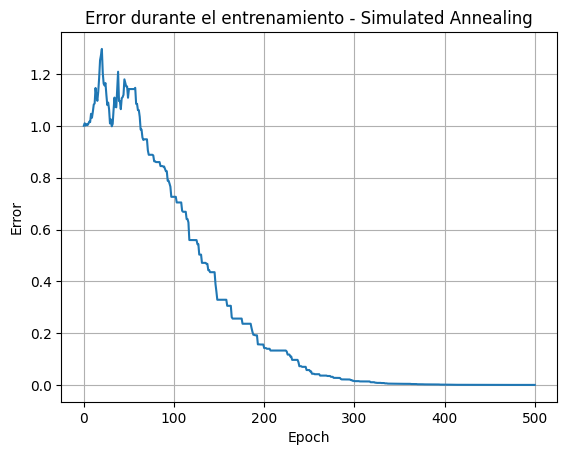

Evaluación de la red después de Simulated Annealing:
Resultado de la red neuronal: [-0.99453882] y resultado: [-1]
Resultado de la red neuronal: [0.99677686] y resultado: [1]
Resultado de la red neuronal: [0.99609483] y resultado: [1]
Resultado de la red neuronal: [-0.99590782] y resultado: [-1]


In [3]:
# Datos XOR
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y = np.array([[-1], [1], [1], [-1]])

# Crear modelo
mlp = MultilayerPerceptron(layer_sizes=[2, 4, 1], activation_function=tanh, activation_derivative=tanh_derivative)

# Entrenamiento con Simulated Annealing
epochs = 500
initial_temp = 300.0
cooling_rate = 0.85
mlp.simulated_annealing(X, y, epochs, initial_temp, cooling_rate)

# Graficar errores
plt.plot(mlp.errors)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error durante el entrenamiento - Simulated Annealing')
plt.grid()
plt.show()

# Evaluar las salidas al final del entrenamiento
print("Evaluación de la red después de Simulated Annealing:")
mlp.evaluate(X, y)

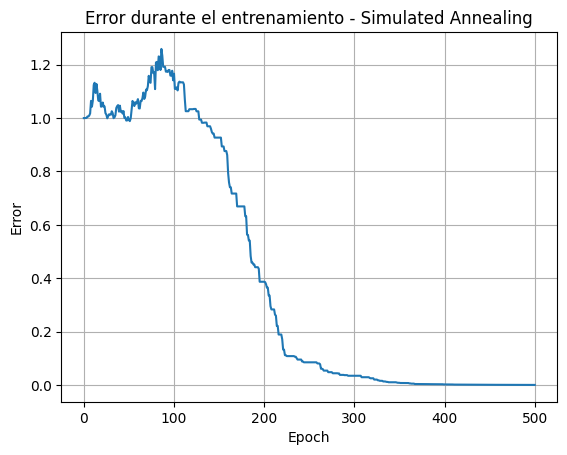

Evaluación de la red después de Simulated Annealing:
Resultado de la red neuronal: [-0.98831301] y resultado: [-1]
Resultado de la red neuronal: [0.99098007] y resultado: [1]
Resultado de la red neuronal: [0.99396101] y resultado: [1]
Resultado de la red neuronal: [-0.9946112] y resultado: [-1]


In [4]:
# Datos XOR
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y = np.array([[-1], [1], [1], [-1]])

# Crear modelo
mlp = MultilayerPerceptron(layer_sizes=[2, 4, 1], activation_function=tanh, activation_derivative=tanh_derivative)

# Entrenamiento con Simulated Annealing
epochs = 500
initial_temp = 100.0
cooling_rate = 0.92
mlp.simulated_annealing(X, y, epochs, initial_temp, cooling_rate)

# Graficar errores
plt.plot(mlp.errors)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error durante el entrenamiento - Simulated Annealing')
plt.grid()
plt.show()

# Evaluar las salidas al final del entrenamiento
print("Evaluación de la red después de Simulated Annealing:")
mlp.evaluate(X, y)

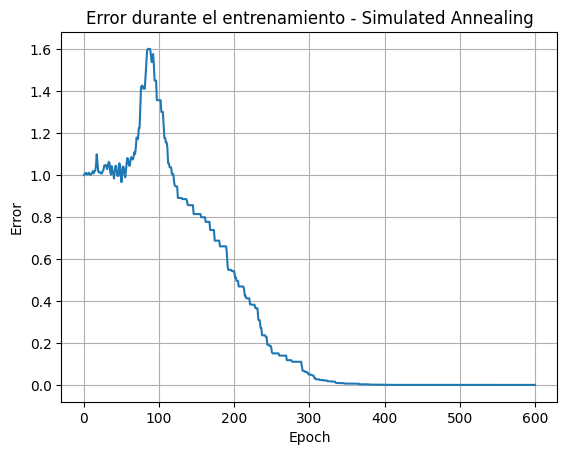

Evaluación de la red después de Simulated Annealing:
Resultado de la red neuronal: [-0.99964367] y resultado: [-1]
Resultado de la red neuronal: [0.99856083] y resultado: [1]
Resultado de la red neuronal: [0.99891766] y resultado: [1]
Resultado de la red neuronal: [-0.99860196] y resultado: [-1]


In [5]:
# Datos XOR
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y = np.array([[-1], [1], [1], [-1]])

# Crear modelo
mlp = MultilayerPerceptron(layer_sizes=[2, 4, 1], activation_function=tanh, activation_derivative=tanh_derivative)

# Entrenamiento con Simulated Annealing
epochs = 600
initial_temp = 300.0
cooling_rate = 0.90
mlp.simulated_annealing(X, y, epochs, initial_temp, cooling_rate)

# Graficar errores
plt.plot(mlp.errors)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error durante el entrenamiento - Simulated Annealing')
plt.grid()
plt.show()

# Evaluar las salidas al final del entrenamiento
print("Evaluación de la red después de Simulated Annealing:")
mlp.evaluate(X, y)

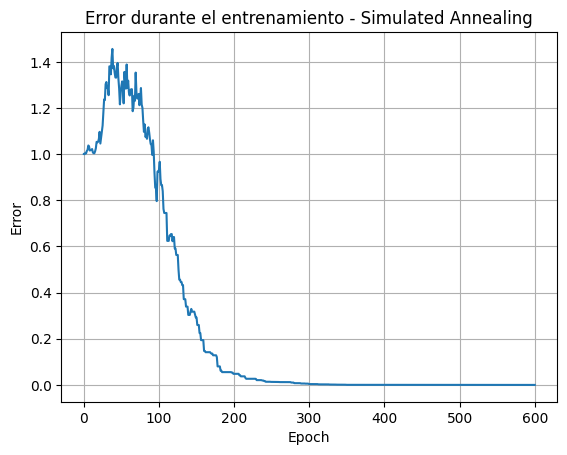

Evaluación de la red después de Simulated Annealing:
Resultado de la red neuronal: [-0.99970122] y resultado: [-1]
Resultado de la red neuronal: [0.99999879] y resultado: [1]
Resultado de la red neuronal: [0.999578] y resultado: [1]
Resultado de la red neuronal: [-0.99967631] y resultado: [-1]


In [6]:
# Datos XOR
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y = np.array([[-1], [1], [1], [-1]])

# Crear modelo
mlp = MultilayerPerceptron(layer_sizes=[2, 4, 1], activation_function=tanh, activation_derivative=tanh_derivative)

# Entrenamiento con Simulated Annealing
epochs = 600
initial_temp = 10.0
cooling_rate = 0.95
mlp.simulated_annealing(X, y, epochs, initial_temp, cooling_rate)

# Graficar errores
plt.plot(mlp.errors)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error durante el entrenamiento - Simulated Annealing')
plt.grid()
plt.show()

# Evaluar las salidas al final del entrenamiento
print("Evaluación de la red después de Simulated Annealing:")
mlp.evaluate(X, y)

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Ejercicio 1

Construya una red de Kohonen de 2 entradas que aprenda una distribución uniforme
dentro del círculo unitario. Mostrar el mapa de preservación de topología. Probar con
distribuciones uniformes dentro de otras figuras geométricas.

In [45]:
class Kohonen:
    def __init__(self, dim, N, filas, columnas):
        self.dim = dim
        self.N = N
        self.filas = filas
        self.columnas = columnas
        # Inicializamos los pesos de la red con distribución normal
        self.w = np.random.normal(0.5, 0.1, (dim, N))  # Pesos de la red (2xN)
        # Matriz de distancias entre las neuronas en la cuadrícula
        self.dist_matrix = self.calcular_distancia_neuronas()

    def calcular_distancia_neuronas(self):
        dist_matrix = np.zeros((self.N, self.N))
        for i in range(self.filas):
            for j in range(self.columnas):
                idx1 = i * self.columnas + j
                for k in range(self.filas):
                    for l in range(self.columnas):
                        idx2 = k * self.columnas + l
                        dist_matrix[idx1, idx2] = np.sqrt((i - k)**2 + (j - l)**2)
        return dist_matrix

    def train(self, X, sigma, eta, epochs, title= ""):
        N_x = X.shape[0]
        min_dists = np.zeros(N_x * epochs)
        sigma_e = sigma
        _, ax = plt.subplots()
        self.mostrar_mapa_topologia(X,ax, 0, title)
        plt.show()

        for e in range(epochs):
            np.random.shuffle(X)
            for i, x in enumerate(X):
                distancias = np.linalg.norm(self.w - x[:, np.newaxis], axis=0)
                winner = np.argmin(distancias)
                min_dists[i + e * N_x] = distancias[winner]

                V = np.exp(-self.dist_matrix[:, winner]**2 / (2 * sigma_e**2))

                delta_w = eta * V * (-self.w.T + x).T
                self.w += delta_w

            # Actualizamos sigma
            sigma_e = sigma_e * 0.99

            #if e == epochs-1 or e % 500 == 0:
            if e == epochs-1:
                _, ax = plt.subplots()
                self.mostrar_mapa_topologia(X,ax, e, title)
                plt.show()

        return min_dists

    def mostrar_mapa_topologia(self, X_train, ax, epoca, title= ""):
        ax.clear()
        ax.set_title(f"Mapa de preservación de topología - Época {epoca} {title}")
        
        # Reshape de los pesos para adaptarlos a la cuadrícula
        w_reshaped = self.w.reshape(2, self.filas, self.columnas)
        
        # Graficar los pesos de las neuronas como puntos en 2D
        ax.plot(w_reshaped[0, :].T, w_reshaped[1, :].T, '-o', color='b')
        ax.plot(w_reshaped[0, :], w_reshaped[1, :], '-o', color='b')
        
        # Graficar los puntos generados con un tamaño de círculo más grande
        ax.scatter(X_train[:, 0], X_train[:, 1], s=30, alpha=0.6, color='black', label='Datos')

        # Agregar leyenda
        ax.legend(loc='upper left')

        ax.axis('equal')
        plt.draw()


# Generar puntos dentro del círculo unitario
def generar_puntos_circulo(n_puntos):
    puntos = []
    while len(puntos) < n_puntos:
        x, y = np.random.uniform(-1, 1, 2)
        if x**2 + y**2 <= 1:  # Puntos dentro del círculo unitario
            puntos.append([x, y])
    return np.array(puntos)

# Funciones para generar puntos dentro de diferentes figuras geométricas

# Cuadrado
def generar_puntos_cuadrado(n_puntos):
    x = np.random.uniform(-1, 1, n_puntos)
    y = np.random.uniform(-1, 1, n_puntos)
    return np.column_stack((x, y))

# Rectángulo
def generar_puntos_rectangulo(n_puntos, ancho, alto):
    x = np.random.uniform(-ancho/2, ancho/2, n_puntos)
    y = np.random.uniform(-alto/2, alto/2, n_puntos)
    return np.column_stack((x, y))

# Triángulo
def generar_puntos_triangulo(n_puntos):
    v1 = np.array([-1, -1])
    v2 = np.array([1, -1])
    v3 = np.array([0, 1])
    puntos = []
    for _ in range(n_puntos):
        r1 = np.random.uniform(0, 1)
        r2 = np.random.uniform(0, 1)
        if r1 + r2 > 1:
            r1 = 1 - r1
            r2 = 1 - r2
        punto = r1 * v1 + r2 * v2 + (1 - r1 - r2) * v3
        puntos.append(punto)
    return np.array(puntos)

# Paralelogramo
def generar_puntos_paralelogramo(n_puntos):
    v1 = np.array([1, 0])
    v2 = np.array([0.5, np.sqrt(3)/2])
    puntos = []
    for _ in range(n_puntos):
        r1 = np.random.uniform(0, 1)
        r2 = np.random.uniform(0, 1)
        punto = r1 * v1 + r2 * v2
        puntos.append(punto)
    return np.array(puntos)





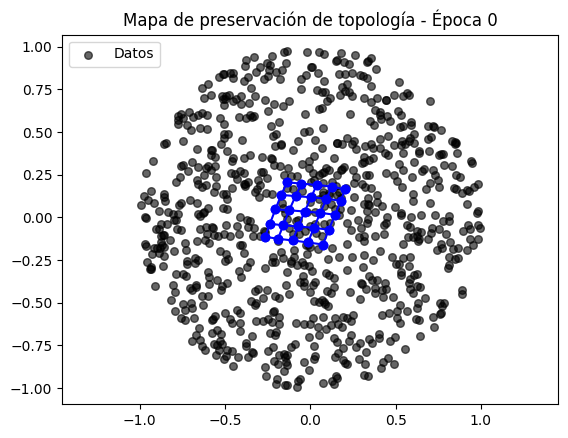

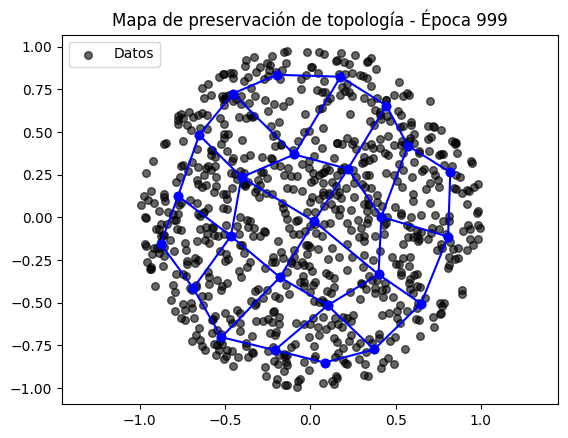

In [16]:
# Parámetros
n_puntos = 800  # Número de puntos
filas = 5        # Número de filas en la cuadrícula
columnas = 5     # Número de columnas en la cuadrícula
n_iter = 1000    # Número de iteraciones

X_train = generar_puntos_circulo(n_puntos)

# Crear un objeto Kohonen
prueba1 = Kohonen(dim=2, N=filas * columnas, filas=filas, columnas=columnas)

# Entrenar la red de Kohonen
e = prueba1.train(X_train, sigma=3, eta=0.01, epochs=1000)

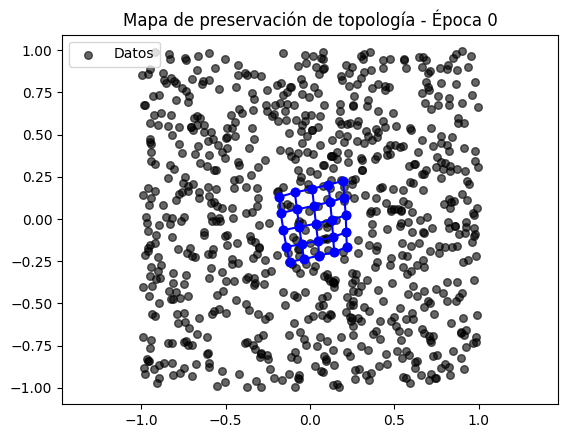

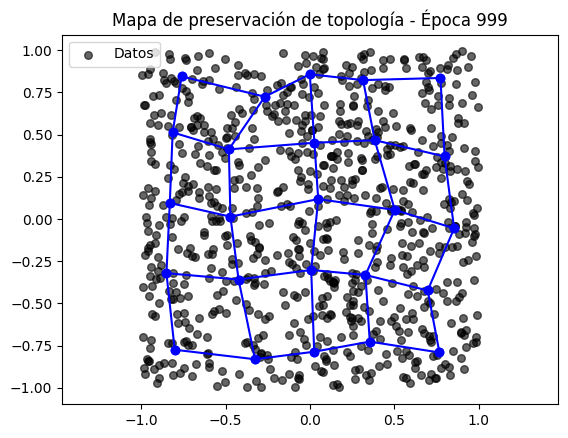

In [9]:
# Parámetros
n_puntos = 800  # Número de puntos
filas = 5        # Número de filas en la cuadrícula
columnas = 5     # Número de columnas en la cuadrícula
n_iter = 1000    # Número de iteraciones

X_train = generar_puntos_cuadrado(n_puntos)

# Crear un objeto Kohonen
prueba1 = Kohonen(dim=2, N=filas * columnas, filas=filas, columnas=columnas)

# Entrenar la red de Kohonen
e = prueba1.train(X_train, sigma=3, eta=0.01, epochs=1000)

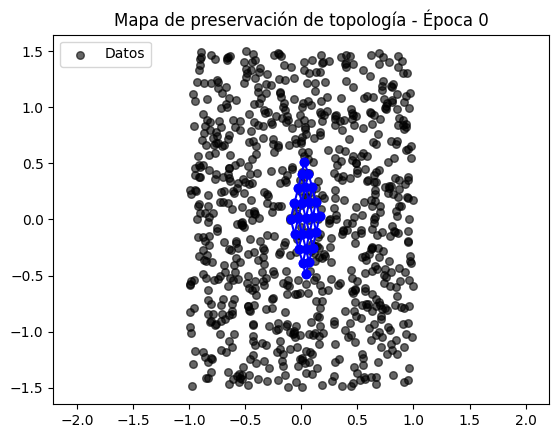

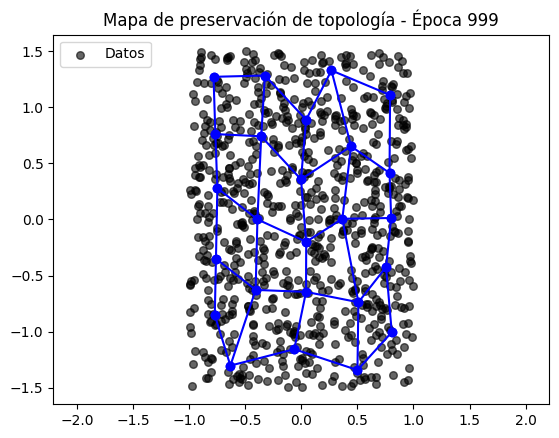

In [10]:
# Parámetros
n_puntos = 800  # Número de puntos
filas = 5        # Número de filas en la cuadrícula
columnas = 5     # Número de columnas en la cuadrícula
n_iter = 1000    # Número de iteraciones

X_train = generar_puntos_rectangulo(n_puntos, 2, 3)

# Crear un objeto Kohonen
prueba1 = Kohonen(dim=2, N=filas * columnas, filas=filas, columnas=columnas)

# Entrenar la red de Kohonen
e = prueba1.train(X_train, sigma=3, eta=0.01, epochs=1000)

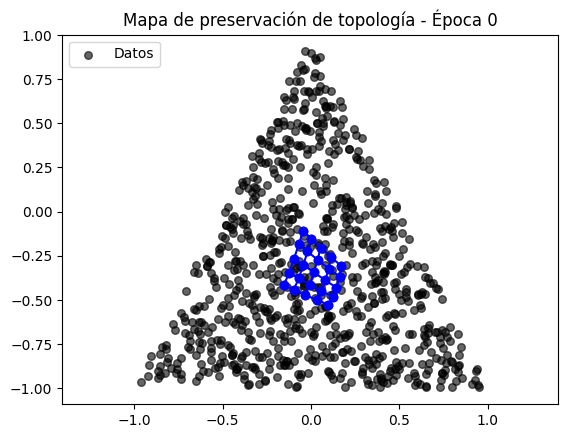

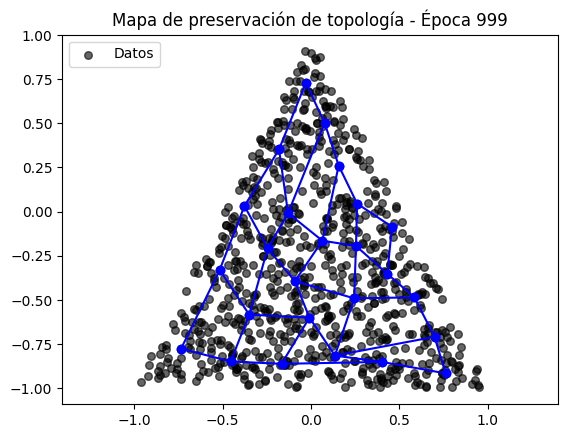

In [11]:
# Parámetros
n_puntos = 800  # Número de puntos
filas = 5        # Número de filas en la cuadrícula
columnas = 5     # Número de columnas en la cuadrícula
n_iter = 1000    # Número de iteraciones

X_train = generar_puntos_triangulo(n_puntos)

# Crear un objeto Kohonen
prueba1 = Kohonen(dim=2, N=filas * columnas, filas=filas, columnas=columnas)

# Entrenar la red de Kohonen
e = prueba1.train(X_train, sigma=3, eta=0.01, epochs=1000)

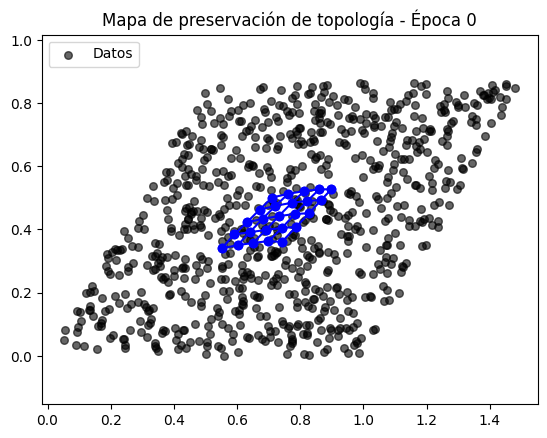

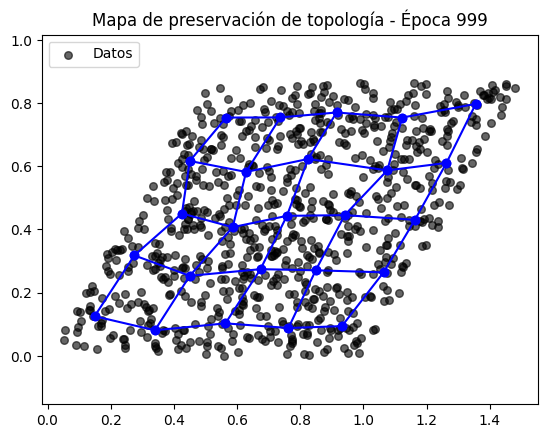

In [12]:
# Parámetros
n_puntos = 800  # Número de puntos
filas = 5        # Número de filas en la cuadrícula
columnas = 5     # Número de columnas en la cuadrícula
n_iter = 1000    # Número de iteraciones

X_train = generar_puntos_paralelogramo(n_puntos)

# Crear un objeto Kohonen
prueba1 = Kohonen(dim=2, N=filas * columnas, filas=filas, columnas=columnas)

# Entrenar la red de Kohonen
e = prueba1.train(X_train, sigma=3, eta=0.01, epochs=1000)

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Ejercicio 2

Resuelva (aproximadamente) el “Traveling salesman problem” para 200 ciudades con
una red de Kohonen.

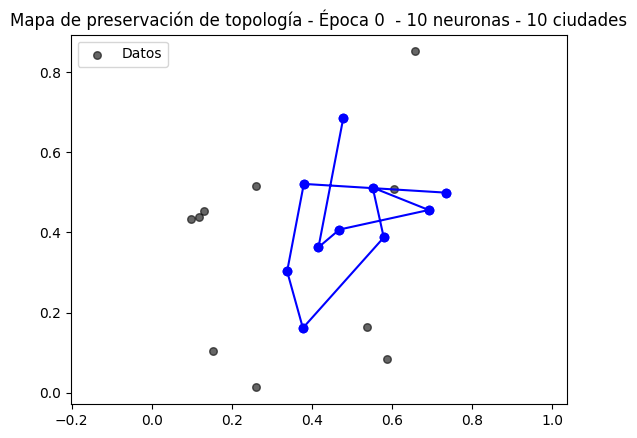

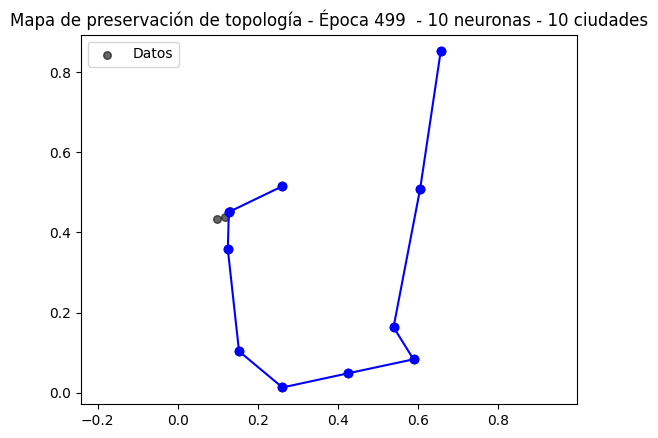

In [46]:
def generar_ciudades(n_ciudades):
    puntos = []
    while len(puntos) < n_ciudades:
        x, y = np.random.uniform(0, 1, 2)
        puntos.append([x, y])
    return np.array(puntos)

# Parámetros
n_ciudades = 10   # Número de puntos
filas = 1        # Número de filas en la cuadrícula


X_train = generar_ciudades(n_ciudades) 

prueba1 = Kohonen(dim=2, N=n_ciudades, filas=filas, columnas=n_ciudades)

e = prueba1.train(X_train, sigma=25, eta=0.8, epochs=500, title = " - 10 neuronas - 10 ciudades")

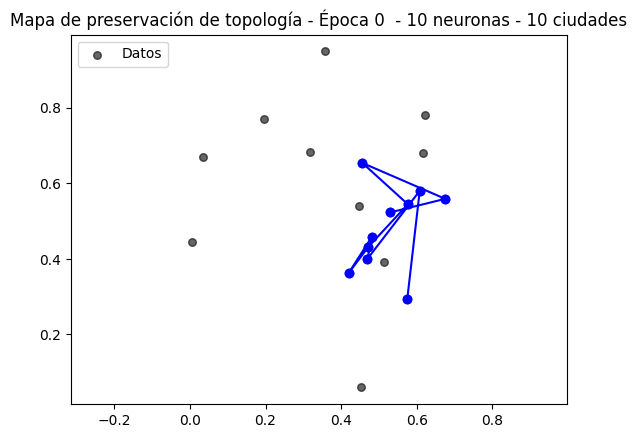

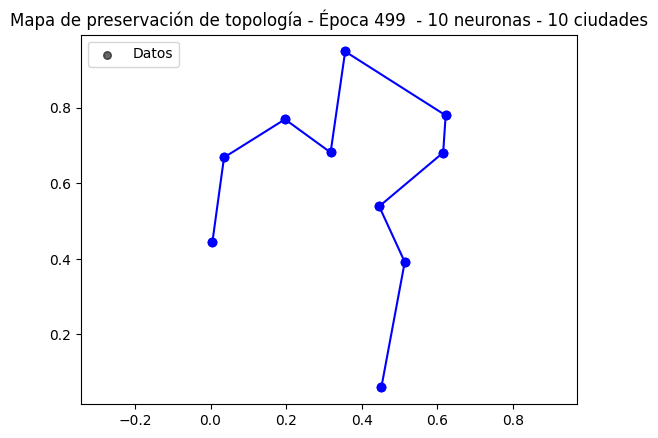

In [51]:
def generar_ciudades(n_ciudades):
    puntos = []
    while len(puntos) < n_ciudades:
        x, y = np.random.uniform(0, 1, 2)
        puntos.append([x, y])
    return np.array(puntos)

# Parámetros
n_ciudades = 10   # Número de puntos
filas = 1        # Número de filas en la cuadrícula


X_train = generar_ciudades(n_ciudades) 

prueba1 = Kohonen(dim=2, N=n_ciudades, filas=filas, columnas=n_ciudades)

e = prueba1.train(X_train, sigma=25, eta=0.8, epochs=500, title = " - 10 neuronas - 10 ciudades")

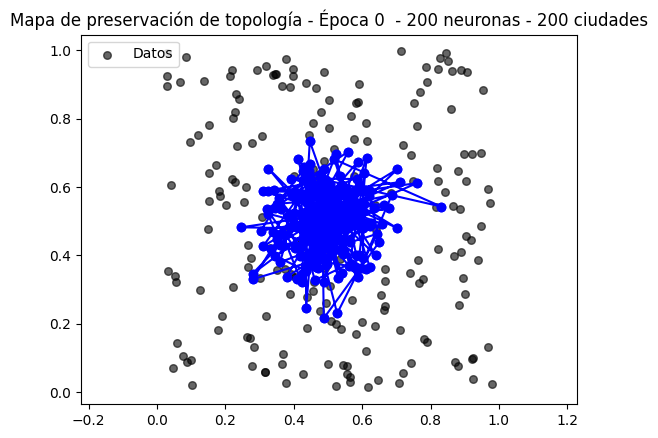

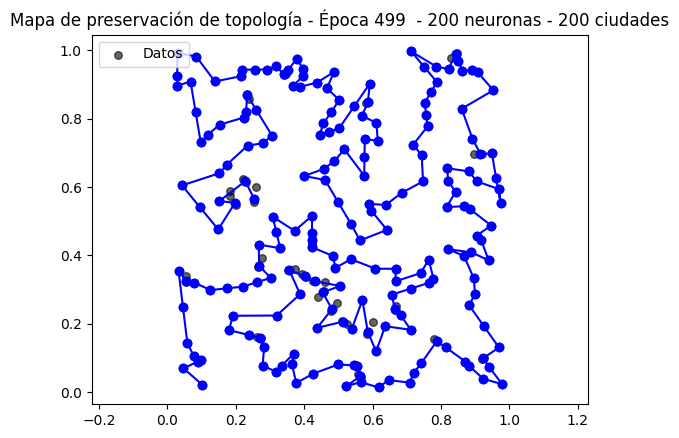

In [55]:
def generar_ciudades(n_ciudades):
    puntos = []
    while len(puntos) < n_ciudades:
        x, y = np.random.uniform(0, 1, 2)
        puntos.append([x, y])
    return np.array(puntos)

# Parámetros
n_ciudades = 200   # Número de puntos
filas = 1        # Número de filas en la cuadrícula


X_train = generar_ciudades(n_ciudades) 

prueba1 = Kohonen(dim=2, N=n_ciudades, filas=filas, columnas=n_ciudades)

e = prueba1.train(X_train, sigma=25, eta=0.8, epochs=500, title = " - 200 neuronas - 200 ciudades")

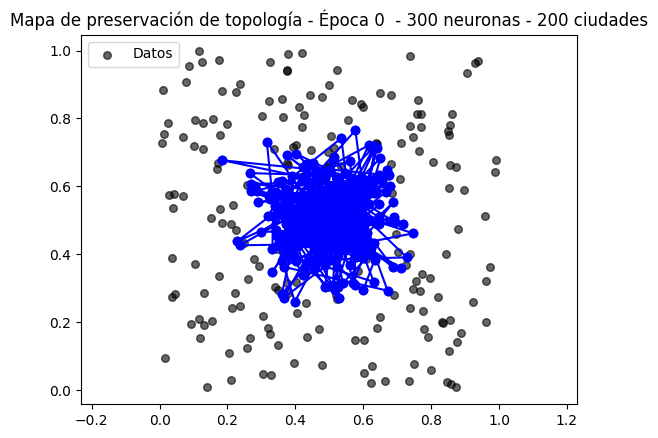

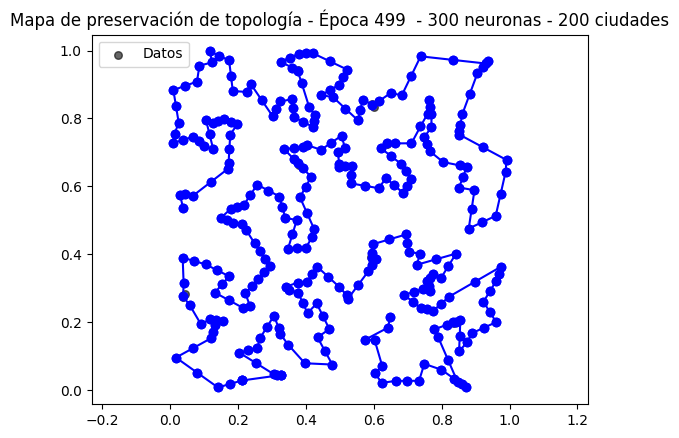

In [54]:
def generar_ciudades(n_ciudades):
    puntos = []
    while len(puntos) < n_ciudades:
        x, y = np.random.uniform(0, 1, 2)
        puntos.append([x, y])
    return np.array(puntos)

# Parámetros
n_ciudades = 200   # Número de puntos
filas = 1        # Número de filas en la cuadrícula


X_train = generar_ciudades(n_ciudades) 

prueba1 = Kohonen(dim=2, N=n_ciudades+100, filas=filas, columnas=n_ciudades+100)

e = prueba1.train(X_train, sigma=25, eta=0.8, epochs=500, title = " - 300 neuronas - 200 ciudades")

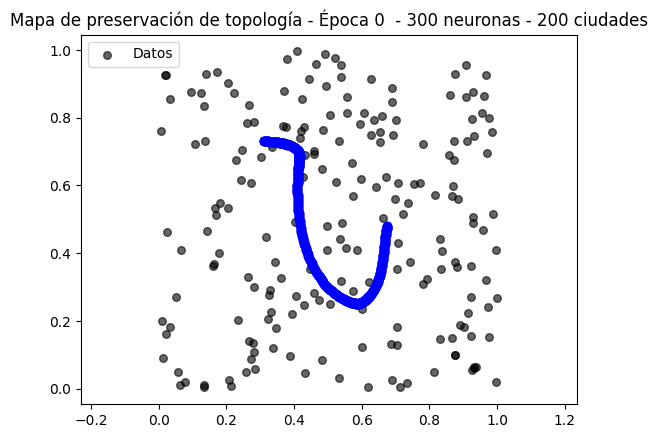

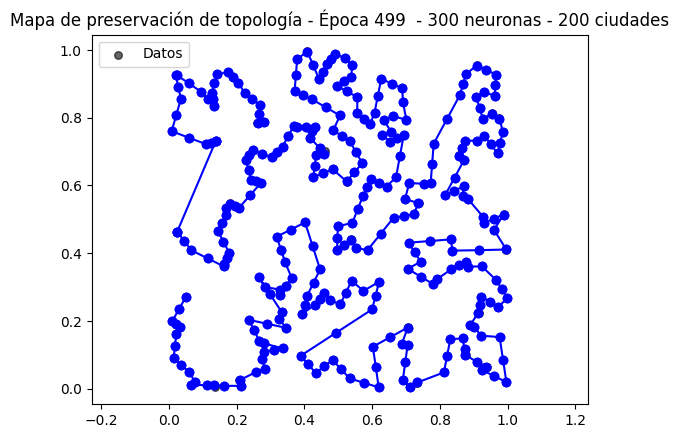

In [41]:
def generar_ciudades(n_ciudades):
    puntos = []
    while len(puntos) < n_ciudades:
        x, y = np.random.uniform(0, 1, 2)
        puntos.append([x, y])
    return np.array(puntos)

# Parámetros
n_ciudades = 200   # Número de puntos
filas = 1        # Número de filas en la cuadrícula


X_train = generar_ciudades(n_ciudades) 

prueba1 = Kohonen(dim=2, N=n_ciudades+100, filas=filas, columnas=n_ciudades+100)

e = prueba1.train(X_train, sigma=50, eta=0.8, epochs=500, title = " - 300 neuronas - 200 ciudades")